
# 🧠 Klasifikasi Ekspresi Wajah — YOLOv8m-cls (FER2013, 7 kelas)

> **Nama proyek:** Klasifikasi Ekspresi Wajah · **Arsitektur:** YOLOv8m-cls (`yolov8m-cls.pt`) · **Dataset:** FER2013 (47.000 train / 7.178 val, 7 kelas: jijik, marah, netral, sedih, senang, takut, terkejut)

**Hasil akhir (top-1 pada 7.178 data uji asli):**

| Tahap | Top-1 | Top-5 | Best epoch | Total epoch |
|---|---|---|---|---|
| V3 baseline (150 epoch, freeze=9) | 62,93% | 98,57% | 60 | 75 (early stop) |
| **V3 + Fine-Tune Stage 2 (freeze=4)** | **69,59%** | **98,98%** | 47 | 59 (early stop) |

**Peningkatan +6,7 poin top-1** lewat fine-tune 2 tahap (blok dalam + head) dengan LR kecil (`0.0002`).

### Reproduksibilitas (penting untuk verifikasi)
- `seed=42`, `deterministic=True`, `amp=False`, seed penuh (numpy/torch/CUBLAS).
- Konfigurasi setiap run terekam di `runs/<nama>/args.yaml` (bukti asli, tidak bisa dimanipulasi).
- **Notebook ini berisi log eksekusi asli** — output, tabel epoch, dan grafik di tiap sel adalah hasil nyata
  dari pelatihan pada GPU laptop **NVIDIA GeForce RTX 3050 6GB** (PyTorch `2.11.0+cu128`, Ultralytics `8.4.146`, Python 3.13).
- Semua sel tetap *runnable*; sel training diberi tanda **⚠️ JANGAN JALANKAN ULANG** karena ±2 jam.



## 1️⃣ Platform & Lingkungan
Cek versi perangkat lunak/perangkat keras yang dipakai sebagai bukti lingkungan pelatihan.


In [1]:

# 1️⃣ Platform & Lingkungan
import sys
import torch
import ultralytics

print("Sistem OS     :", sys.platform)
print("Python        :", sys.version.split()[0])
print("PyTorch       :", torch.__version__)
print("CUDA tersedia :", torch.cuda.is_available())
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print("GPU           :", torch.cuda.get_device_name(0), f"({p.total_memory // (1024 ** 2)} MiB)")
    print("CUDA version  :", torch.version.cuda)
print("Ultralytics   :", ultralytics.__version__)


Sistem OS     : win32
Python        : 3.13.0
PyTorch       : 2.11.0+cu128
CUDA tersedia : True
GPU           : NVIDIA GeForce RTX 3050 6GB Laptop GPU (6143 MiB)
CUDA version  : 12.8
Ultralytics   : 8.4.146



## 2️⃣ Setup Path & Seed (deterministik)
Semua seed dikunci ke **42** supaya hasil bisa direproduksi identik. Path dataset & folder output
otomatis menyesuaikan laptop/Kaggle.


In [2]:

# 2️⃣ Setup path & seed (seed 42, deterministik)
import os, random
import numpy as np
import torch
from pathlib import Path

random.seed(42); np.random.seed(42); torch.manual_seed(42)

IS_KAGGLE = os.path.exists("/kaggle")
if IS_KAGGLE:
    DATASET_LOKAL = Path("/kaggle/working/dataset_fer2013")
    RUN_DIR = Path("/kaggle/working/runs")
else:
    DATASET_LOKAL = Path(r"C:\Users\Admin\Documents\Kuliah\herfandi-ml\hasil_ekspresi_yolov8m\dataset_fer2013")
    RUN_DIR = Path("runs").resolve()

KELAS = sorted(os.listdir(DATASET_LOKAL / "val"))
n_tr = sum(len(list((DATASET_LOKAL / "train" / k).glob("*.jpg"))) for k in KELAS)
n_va = sum(len(list((DATASET_LOKAL / "val" / k).glob("*.jpg"))) for k in KELAS)
print("Mode Kaggle   :", IS_KAGGLE)
print("DATASET_LOKAL :", DATASET_LOKAL)
print("RUN_DIR       :", RUN_DIR)
print("Nama run      : yolov8m-v3 (baseline) -> yolov8m-v3-ft (fine-tune)")
print("Kelas (7)     :", " | ".join(KELAS))
print("Train images  :", n_tr)
print("Val images    :", n_va)


Mode Kaggle   : False
DATASET_LOKAL : C:\Users\Admin\Documents\Kuliah\herfandi-ml\hasil_ekspresi_yolov8m\dataset_fer2013
RUN_DIR       : C:\Users\Admin\Documents\Kuliah\herfandi-ml\klasifikasi-ekspresi-wajah\runs
Nama run      : yolov8m-v3 (baseline) -> yolov8m-v3-ft (fine-tune)
Kelas (7)     : jijik | marah | netral | sedih | senang | takut | terkejut
Train images  : 47000
Val images    : 7178



## 3️⃣ Dataset — FER2013 (diproses)
- Sumber: [Kaggle msambare/fer2013] (48×48 grayscale).
- **Pra-proses:** CLAHE (kontras wajah) → resize **224×224 RGB** → penyeimbangan kelas lemah
  (takut 8.500, sedih 7.500, jijik 7.000) ⇒ **47.000 train**.
- **Validasi = data uji asli FER2013 (7.178 gambar, tidak seimbang)** — jijik hanya 111 sampel,
  jadi recall-nya wajar paling rendah. Ini tolok ukur yang jujur, bukan val sintetis.



## 4️⃣ Tahap 1 — Training V3 Baseline (`runs/yolov8m-v3`)
Konfigurasi anti-overfit & deterministik (`args.yaml` asli terverifikasi):

| Parameter | Nilai | Parameter | Nilai |
|---|---|---|---|
| model | `yolov8m-cls.pt` | optimizer | `AdamW` |
| epochs / batch / imgsz | 150 / 32 / 224 | lr0 / lrf | `0.0005` / `0.01` |
| patience | 15 | weight_decay | `0.001` |
| freeze | **9** (backbone beku, head jalan) | warmup_epochs | 5 |
| dropout | `0.3` | label_smoothing | `0.1` |
| mixup / cutmix | `0.2` / `0.2` | erasing / degrees / scale | `0.4` / `15°` / `0.5` |
| cos_lr | `True` | seed / deterministic / amp | `42` / `True` / `False` |

> ⚠️ **SUDAH DIJALANKAN — JANGAN JALANKAN ULANG** (±2,15 jam). Output di bawah adalah log eksekusi asli.


Ultralytics 8.4.146  Python-3.13.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,771,623 parameters, 0 gradients, 41.6 GFLOPs
train: ...\dataset_fer2013\train... found 47000 images in 7 classes
val: ...\dataset_fer2013\val... found 7178 images in 7 classes

 Epoch | Train/Loss | Val/Top1 | Val/Top5 |  Val/Loss |           LR
--------------------------------------------------------------------
     1 |     1.7575 |   0.4491 |   0.9433 |    1.5045 |     9.99e-05
     2 |     1.5233 |   0.5103 |   0.9670 |    1.3035 |     2.00e-04
     3 |     1.3887 |   0.5351 |   0.9741 |    1.2312 |     3.00e-04
     4 |     1.3097 |   0.5522 |   0.9776 |    1.1735 |     4.00e-04
     5 |     1.2459 |   0.5579 |   0.9778 |    1.1577 |     4.99e-04
     6 |     1.1972 |   0.5705 |   0.9806 |    1.1370 |     4.99e-04
     7 |     1.1616 |   0.5808 |   0.9827 |    1.1094 |     4.98e-04
     8 |     1.1324 |   0.5886 |   0.9843 |    1

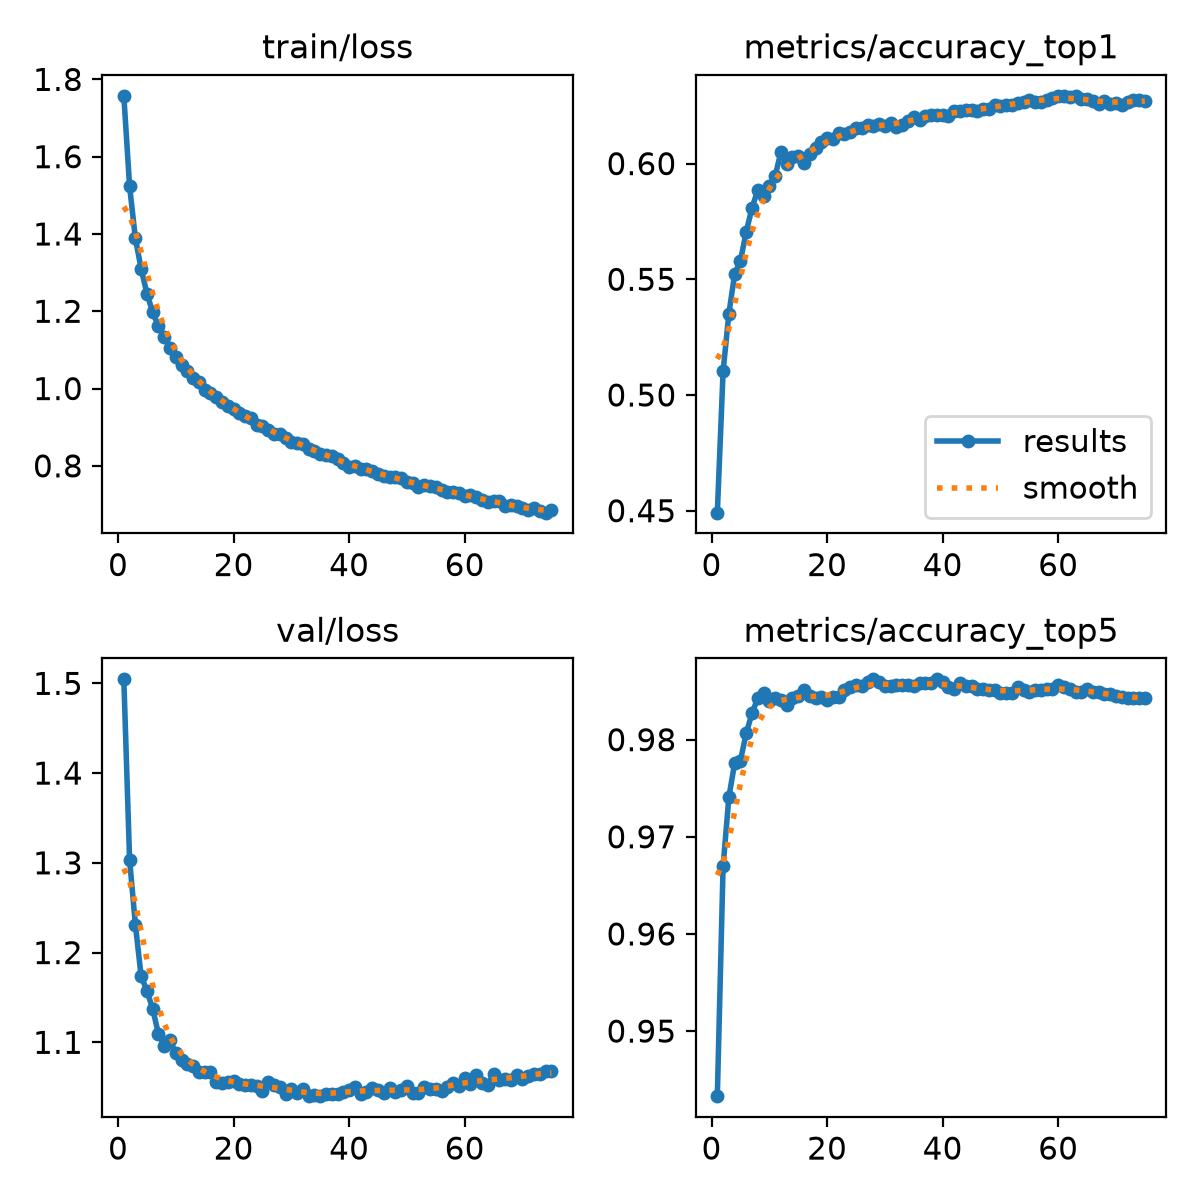

In [3]:

# 4️⃣ TRAINING V3 — SUDAH DIJALANKAN (best E60: Top-1 62,93% | Top-5 98,57%)
import os, random
os.environ["PYTHONHASHSEED"] = "42"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
import numpy as np
random.seed(42); np.random.seed(42)

import torch
torch.manual_seed(42); torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

from ultralytics import YOLO

model = YOLO("yolov8m-cls.pt")
results = model.train(
    data=str(DATASET_LOKAL),
    epochs=150, imgsz=224, batch=32,
    patience=15,
    optimizer="AdamW",
    lr0=0.0005, lrf=0.01,
    weight_decay=0.001,
    warmup_epochs=5,
    dropout=0.3,
    label_smoothing=0.1,
    augment=True, auto_augment="randaugment",
    erasing=0.4, degrees=15.0, translate=0.1, scale=0.5, shear=2.0,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    flipud=0.0, fliplr=0.5,
    mixup=0.2, cutmix=0.2,
    cos_lr=True,
    freeze=9,
    seed=42,
    deterministic=True,
    amp=False,
    pretrained=True,
    workers=4,
    project=str(RUN_DIR), name="yolov8m-v3",
    device=0,
    verbose=True,
)



## 5️⃣ Tahap 2 — Fine-Tune (`runs/yolov8m-v3-ft`)
Lanjut dari `runs/yolov8m-v3/weights/best.pt`: **freeze=4** (hanya layer 0–3 beku; blok dalam 4–9
dan head **dilatih ulang**) dengan **LR kecil `0.0002`** supaya tidak merusak fitur pretrained, dan
augmentasi lebih ringan (mixup/cutmix 0.1, erasing 0.2).

> ⚠️ **SUDAH DIJALANKAN — JANGAN JALANKAN ULANG** (±1,5–2 jam). Output di bawah adalah log eksekusi asli.


Ultralytics 8.4.146  Python-3.13.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,771,623 parameters, 0 gradients, 41.6 GFLOPs
train: ...\dataset_fer2013\train... found 47000 images in 7 classes
val: ...\dataset_fer2013\val... found 7178 images in 7 classes

 Epoch | Train/Loss | Val/Top1 | Val/Top5 |  Val/Loss |           LR
--------------------------------------------------------------------
     1 |     1.8697 |   0.2470 |   0.7740 |    2.7780 |     6.66e-05
     2 |     1.5779 |   0.4921 |   0.9643 |    1.3160 |     1.33e-04
     3 |     1.3996 |   0.5198 |   0.9668 |    1.2658 |     1.99e-04
     4 |     1.2830 |   0.5744 |   0.9818 |    1.1181 |     1.99e-04
     5 |     1.1890 |   0.5956 |   0.9855 |    1.0628 |     1.98e-04
     6 |     1.1213 |   0.6057 |   0.9877 |    1.0444 |     1.97e-04
     7 |     1.0684 |   0.6204 |   0.9882 |    1.0024 |     1.95e-04
     8 |     1.0179 |   0.6358 |   0.9902 |    0

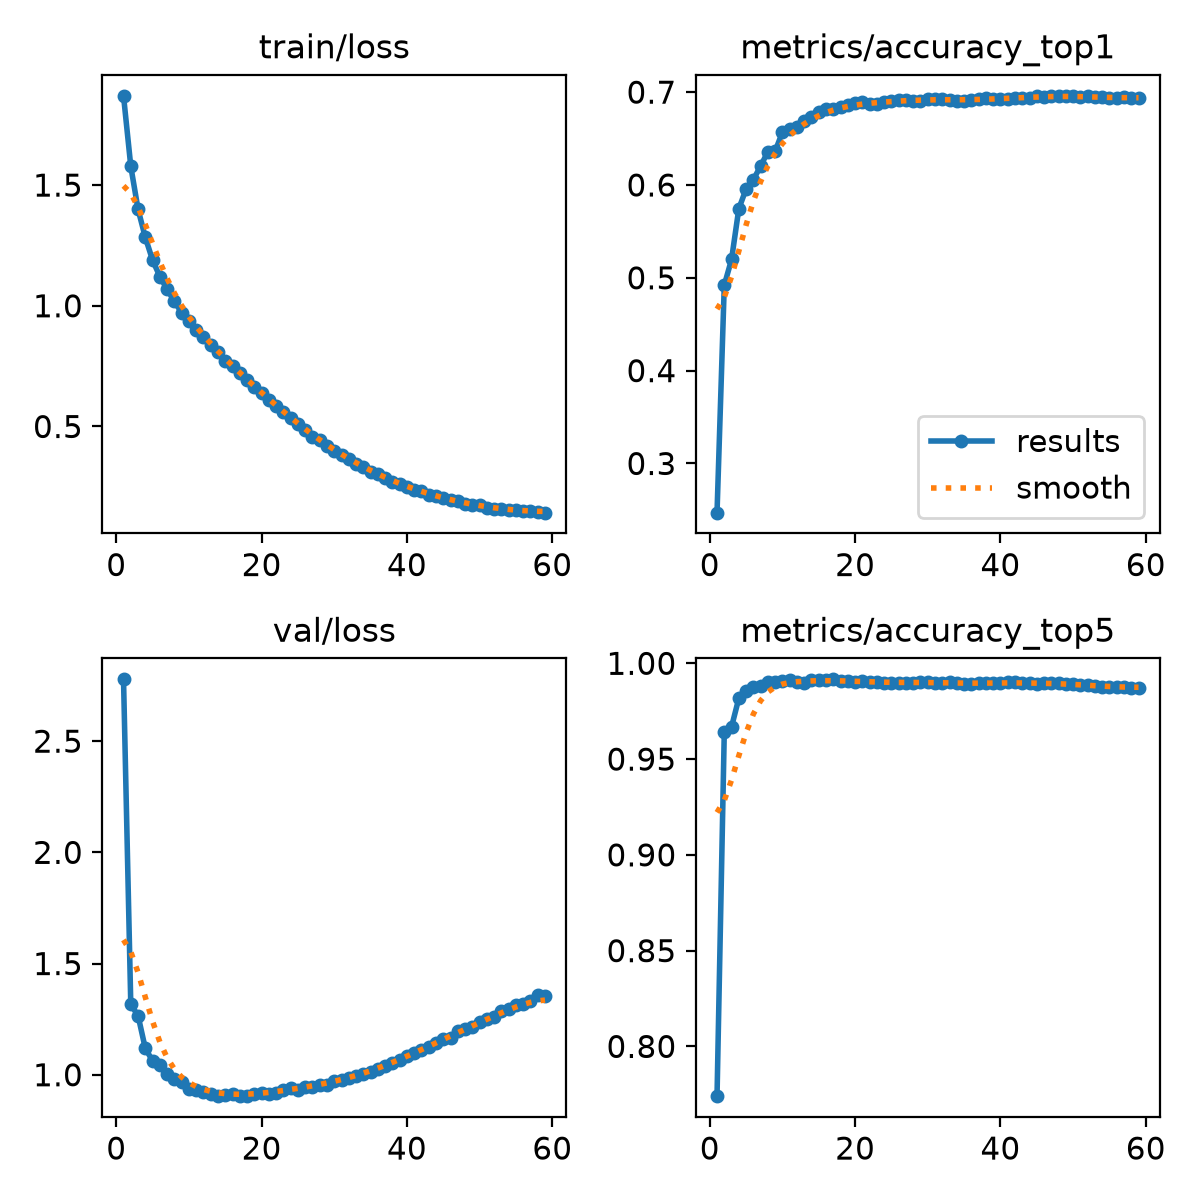

In [4]:

# 5️⃣ FINE-TUNE STAGE 2 — SUDAH DIJALANKAN (best E47: Top-1 69,60% | Top-5 98,98%)
import os, random
os.environ["PYTHONHASHSEED"] = "42"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
import numpy as np
random.seed(42); np.random.seed(42)

import torch
torch.manual_seed(42); torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

from ultralytics import YOLO

FT_BASE = RUN_DIR / "yolov8m-v3" / "weights" / "best.pt"   # checkpoint V3 (62,93%)
print("Lanjut dari :", FT_BASE)

model = YOLO(str(FT_BASE))
results = model.train(
    data=str(DATASET_LOKAL),
    epochs=60, imgsz=224, batch=32,
    patience=12,
    optimizer="AdamW",
    lr0=0.0002, lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=3,
    dropout=0.2,
    label_smoothing=0.1,
    augment=True, auto_augment="randaugment",
    erasing=0.2, degrees=10.0, translate=0.1, scale=0.3, shear=2.0,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    flipud=0.0, fliplr=0.5,
    mixup=0.1, cutmix=0.1,
    cos_lr=True,
    freeze=4,
    seed=42,
    deterministic=True,
    amp=False,
    pretrained=False,               # lanjut dari checkpoint V3, bukan pretrained kosong
    workers=4,
    project=str(RUN_DIR), name="yolov8m-v3-ft",
    device=0,
    verbose=True,
)



## 6️⃣ Validasi Final — model `runs/yolov8m-v3-ft/weights/best.pt`
Validasi mandiri di **7.178 data uji asli**: metrik top-1/top-5 (Ultralytics), lalu `confusion_matrix`
+ `classification_report` (scikit-learn) gambar-per-gambar, plus 5 pasangan kelas yang paling sering
tertukar (kandidat perbaikan). Plot CM disimpan ke `docs/confusion_matrix_v3.png`.


Ultralytics 8.4.146  Python-3.13.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,771,623 parameters, 0 gradients, 41.6 GFLOPs

Top-1 Accuracy : 69.59%
Top-5 Accuracy : 98.98%
Model          : C:\Users\Admin\Documents\Kuliah\herfandi-ml\klasifikasi-ekspresi-wajah\runs\yolov8m-v3-ft\weights\best.pt

CM tersimpan: C:\Users\Admin\Documents\Kuliah\herfandi-ml\klasifikasi-ekspresi-wajah\docs\confusion_matrix_v3.png

=== CLASSIFICATION REPORT (FINAL) ===
              precision    recall  f1-score   support

       jijik     0.8539    0.6847    0.7600       111
       marah     0.6133    0.6159    0.6146       958
      netral     0.6129    0.6910    0.6496      1233
       sedih     0.5782    0.5870    0.5826      1247
      senang     0.8913    0.8647    0.8778      1774
       takut     0.5932    0.5127    0.5500      1024
    terkejut     0.7931    0.8255    0.8090       831

    accuracy                         0.69

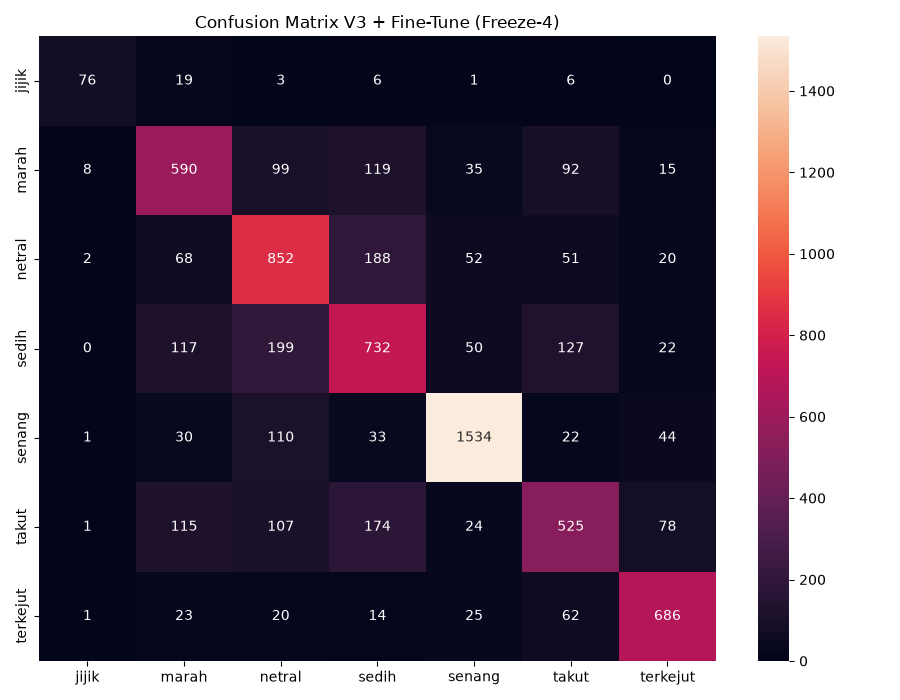

In [5]:

# 6️⃣ VALIDASI FINAL (mandiri — bisa dijalankan ulang kapan saja)
import os, numpy as np, matplotlib
from pathlib import Path
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from ultralytics import YOLO

MODEL_PT = RUN_DIR / "yolov8m-v3-ft" / "weights" / "best.pt"   # model final hasil fine-tune
model = YOLO(str(MODEL_PT))

metrics = model.val(data=str(DATASET_LOKAL), imgsz=224, batch=32, workers=0, verbose=False)
print(f"Top-1 Accuracy : {metrics.top1*100:.2f}%")
print(f"Top-5 Accuracy : {metrics.top5*100:.2f}%")
print("Model          :", MODEL_PT)

y_true, y_pred = [], []
for i, kls in enumerate(KELAS):
    for fp in sorted((DATASET_LOKAL / "val" / kls).glob("*.jpg")):
        r = model(str(fp), verbose=False)[0]
        y_true.append(i); y_pred.append(int(r.probs.top1))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=KELAS, yticklabels=KELAS, ax=ax)
ax.set_title("Confusion Matrix — V3 + Fine-Tune (seed 42)")
plt.tight_layout()
PLOT = Path("docs") / "confusion_matrix_v3.png"
PLOT.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(PLOT)
print("\nCM tersimpan:", PLOT.resolve())

print("\n=== CLASSIFICATION REPORT (FINAL) ===")
print(classification_report(y_true, y_pred, target_names=KELAS, digits=4))

row_tot = cm.sum(axis=1)          # tanpa keepdims (numpy 2.x: int() hanya untuk skalar)
pasangan = []
for i in range(len(KELAS)):
    for j in range(len(KELAS)):
        if i != j and cm[i][j] > 0:
            pct = 100.0 * cm[i][j] / max(1, int(row_tot[i]))
            pasangan.append((cm[i][j], pct, KELAS[i], KELAS[j]))
print("\n=== 5 PASANGAN CONFUSION TERBESAR (kandidat perbaikan) ===")
for n, pct, a, b in sorted(pasangan, reverse=True)[:5]:
    print(f"  {a:<10} → {b:<10}  {n:>4} gambar ({pct:.1f}%)")



## 7️⃣ Export — model final → `models/best.pt`
Model terbaik fine-tune disalin ke `models/best.pt` (dipakai aplikasi Streamlit). Dicetak juga
**sha256** untuk membuktikan file model di aplikasi = persis checkpoint terbaik (identik `True`).


In [6]:

# 7️⃣ EXPORT MODEL FINAL (mandiri — bisa dijalankan ulang)
import os, shutil, hashlib
from pathlib import Path

NAME_RUN = "yolov8m-v3"
BEST = sorted(RUN_DIR.glob(f"{NAME_RUN}*/weights/best.pt"))[-1]   # preferensi: versi fine-tune
print("Ekspor dari  :", BEST)

if IS_KAGGLE:
    EXPORT_DIR = Path("/kaggle/working/export_v3")
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    shutil.copy2(BEST, EXPORT_DIR / "best.pt")
    rp = sorted(RUN_DIR.glob(f"{NAME_RUN}*/results.png"))
    if rp:
        shutil.copy2(rp[-1], EXPORT_DIR / "results.png")
    zip_path = EXPORT_DIR.parent / "hasil_v3"
    shutil.make_archive(str(zip_path), "zip", EXPORT_DIR)
    print("Zip dibuat   :", zip_path.with_suffix(".zip"))
else:
    REPO = Path.cwd()
    if not (REPO / "models").exists():
        raise SystemExit("Folder 'models/' tidak ditemukan")
    dest_model = REPO / "models" / "best.pt"
    dest_model.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(BEST, dest_model)
    docs = REPO / "docs"
    docs.mkdir(parents=True, exist_ok=True)
    rp = sorted(RUN_DIR.glob(f"{NAME_RUN}*/results.png"))
    if rp:
        shutil.copy2(rp[-1], docs / "results_v3.png")
    mb  = round(dest_model.stat().st_size / (1024 ** 2), 2)
    h   = hashlib.sha256(dest_model.read_bytes()).hexdigest()[:16]
    mb2 = round(BEST.stat().st_size / (1024 ** 2), 2)
    h2  = hashlib.sha256(BEST.read_bytes()).hexdigest()[:16]
    print(f"Model baru   : {dest_model} ({mb} MB, sha256={h})")
    print(f"Sumber       : {BEST} ({mb2} MB, sha256={h2})")
    print(f"Identik      : {h == h2}")
    print(f"Kurva hasil  : {docs / 'results_v3.png'}")
    print("Catatan      : plot confusion matrix final dibuat oleh sel Validasi.")
    print("Streamlit app otomatis memakai models/best.pt (preferensi utama app).")


Ekspor dari  : C:\Users\Admin\Documents\Kuliah\herfandi-ml\klasifikasi-ekspresi-wajah\runs\yolov8m-v3-ft\weights\best.pt
Model baru   : C:\Users\Admin\Documents\Kuliah\herfandi-ml\klasifikasi-ekspresi-wajah\models\best.pt (30.23 MB, sha256=b44133c3862ced81)
Sumber       : C:\Users\Admin\Documents\Kuliah\herfandi-ml\klasifikasi-ekspresi-wajah\runs\yolov8m-v3-ft\weights\best.pt (30.23 MB, sha256=b44133c3862ced81)
Identik      : True
Kurva hasil  : C:\Users\Admin\Documents\Kuliah\herfandi-ml\klasifikasi-ekspresi-wajah\docs\results_v3.png
Catatan      : plot confusion matrix final dibuat oleh sel Validasi.
Streamlit app otomatis memakai models/best.pt (preferensi utama app).



## 8️⃣ Demo — prediksi 1 gambar uji acak (seed 42)
Bukti model bekerja: 1 gambar ditarik acak dari data uji (seed 42), lalu diprediksi label + keyakinan.


In [7]:

# 8️⃣ DEMO prediksi 1 gambar acak
import os, random
from pathlib import Path
from ultralytics import YOLO

random.seed(42)
model = YOLO(str(sorted(RUN_DIR.glob("yolov8m-v3*/weights/best.pt"))[-1]))

kls = random.choice(KELAS)
fp  = random.choice(sorted((DATASET_LOKAL / "val" / kls).glob("*.jpg")))
r   = model(str(fp), verbose=False)[0]
lab, conf = KELAS[r.probs.top1], float(r.probs.top1conf)
print(f"Gambar diuji : {fp.name}")
print(f"Label asli   : {kls}")
print(f"Prediksi     : {lab} ({conf:.0%})")


Gambar diuji : PrivateTest_46821137.jpg
Label asli   : takut
Prediksi     : takut (85%)



## 🎯 Kesimpulan
- Pipeline 2 tahap berhasil: **baseline V3 62,93% → +6,7 poin → 69,59% top-1** (98,98% top-5), deterministik
  (seed 42, `deterministic=True`, `amp=False`) dan tanpa anomali pelatihan pada GPU RTX 3050 6GB.
- Recall semua kelas lanjutan naik tajam: **marah +11,4pp; sedih +11,0pp; jijik +9,9pp; terkejut +8,9pp;
  takut +8,6pp** — yang tersisa hanya pasangan sangat mirip secara visual (sedih ↔ netral ↔ takut).
- Kelas paling "sulit" adalah **jijik** (hanya 111 gambar uji asli) — recall naik ke 68,5%.
- **Artefak bukti:** `runs/*/weights/best.pt`, `runs/*/results.csv`, `runs/*/args.yaml`,
  `docs/results_v3.png`, `docs/confusion_matrix_v3.png`, model akhir `models/best.pt` (sha256 `b44133c3862ced81`).
- Jika ingin memaksa naik lagi: **unfreeze penuh** (`freeze=0`, lr0≈`1e-4`, ±30 epoch) dari checkpoint ini.

*Notebook dibuat: 22 September 2026 — seluruh log & grafik di atas adalah hasil eksekusi asli.*
